# Multi-class COVID-19 Detection from Chest X-ray Images 

# install packages for the dataset

In [1]:
!pip3 install torch torchvision torchaudio 


In [2]:
from torchvision import datasets,transforms

path = r"E:/4th semester/python/code/Covid19-dataset/train"

transformation = transforms.Compose( [
    transforms.Resize((128,128)),
    transforms.ToTensor() ]
)

dataset = datasets.ImageFolder(path,transform=transformation)
dataset

Dataset ImageFolder
    Number of datapoints: 251
    Root location: E:/4th semester/python/code/Covid19-dataset/train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

In [4]:
import torch
from torch import nn, optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Dataset path
path = r"E:/4th semester/python/code/Covid19-dataset/train"

# Transformations
transformation = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor()
])

# Load dataset
dataset = datasets.ImageFolder(path, transform=transformation)
dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Define CNN
class SimpleCNN(nn.Module):
    def __init__(self, in_channels):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, 16, kernel_size=5)
        self.pool1 = nn.MaxPool2d(kernel_size=5, stride=5)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3)
        self.pool2 = nn.MaxPool2d(kernel_size=3, stride=3)
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(32*7*7, 1080)
        self.fc2 = nn.Linear(1080, 512)
        self.fc3 = nn.Linear(512, 32)
        self.fc4 = nn.Linear(32, 1)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        x = self.relu(self.conv1(x))
        x = self.pool1(x)
        x = self.relu(self.conv2(x))
        x = self.pool2(x)
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.relu(self.fc2(x))
        x = self.relu(self.fc3(x))
        x = self.fc4(x)  # no sigmoid here
        return x

# Get input channels
img, label = dataset[0]
in_channels = img.shape[0]

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize model, loss, optimizer
model = SimpleCNN(in_channels).to(device)
criterion = nn.BCEWithLogitsLoss()  # handles sigmoid internally
optimizer = optim.Adam(model.parameters(), lr=0.001)
num_epochs = 10

# Training loop
for epoch in range(1, num_epochs + 1):
    total_loss = 0
    model.train()
    for x, y in dataloader:
        x, y = x.to(device), y.view(-1, 1).float().to(device)  # reshape y to match output
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch}/{num_epochs} - Loss: {total_loss:.4f}")


Epoch 1/10 - Loss: 3.7752
Epoch 2/10 - Loss: 1.7322
Epoch 3/10 - Loss: -2.0076
Epoch 4/10 - Loss: -33.2030
Epoch 5/10 - Loss: -299.6049
Epoch 6/10 - Loss: -1417.8371
Epoch 7/10 - Loss: -5133.4755
Epoch 8/10 - Loss: -18968.3494
Epoch 9/10 - Loss: -66735.0396
Epoch 10/10 - Loss: -183355.6279


In [6]:
#muticlass classification CNN

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Load MNIST dataset
dataset = datasets.MNIST(root='E:/4th semester/python/code/Covid19-dataset/train',
                         train=True,
                         download=True,
                         transform=transforms.ToTensor())

dataloader = DataLoader(dataset, shuffle=True, batch_size=64)
img, label = dataset[0]

in_channel, width, height = img.shape
output = len(dataset.classes)

# Define Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self, in_channel, width, height, output):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channel, 16, kernel_size=5, stride=1)
        self.pool1 = nn.AvgPool2d(kernel_size=3)  # Avg Pooling
        
        self.flatten = nn.Flatten()
        
        # Calculate dimensions after convolution and pooling
        conv_output_w = (width + 2*1 - 5) // 1 + 1
        conv_output_h = (height + 2*1 - 5) // 1 + 1
        pool_output_w = (conv_output_w - 3) // 3 + 1
        pool_output_h = (conv_output_h - 3) // 3 + 1

        self.fc1 = nn.Linear(16 * pool_output_w * pool_output_h, 64)
        self.fc2 = nn.Linear(64, output)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model, loss function and optimizer
model = SimpleCNN(in_channel, width, height, output)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
num_epoch = 10

# Training loop
for epoch in range(0, num_epoch+1):
    total_loss = 0
    model.train()
    
    for x, y in dataloader:
        output = model(x)
        loss = criterion(output, y)
        total_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch}/{num_epoch}] Loss: {total_loss}")


100.0%
100.0%
100.0%
100.0%


Epoch [0/10] Loss: 341.5846970900893
Epoch [1/10] Loss: 157.31910816021264
Epoch [2/10] Loss: 116.31726698856801
Epoch [3/10] Loss: 95.03693178854883
Epoch [4/10] Loss: 81.82939272536896
Epoch [5/10] Loss: 71.69406358432025
Epoch [6/10] Loss: 63.35910857189447
Epoch [7/10] Loss: 56.89539496949874
Epoch [8/10] Loss: 51.29824542219285
Epoch [9/10] Loss: 47.63479342474602
Epoch [10/10] Loss: 43.895168845774606


In [7]:
#muticlass classification CNN

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Load MNIST dataset
dataset = datasets.MNIST(root='E:/4th semester/python/code/Covid19-dataset/train',
                         train=True,
                         download=True,
                         transform=transforms.ToTensor())

dataloader = DataLoader(dataset, shuffle=True, batch_size=64)
img, label = dataset[0]

in_channel, width, height = img.shape
output = len(dataset.classes)

# Define Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self, in_channel, width, height, output):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channel, 16, kernel_size=5, stride=1)
        self.pool1 = nn.AvgPool2d(kernel_size=3)  # Avg Pooling
        
        self.flatten = nn.Flatten()
        
        # Calculate dimensions after convolution and pooling
        conv_output_w = (width + 2*1 - 5) // 1 + 1
        conv_output_h = (height + 2*1 - 5) // 1 + 1
        pool_output_w = (conv_output_w - 3) // 3 + 1
        pool_output_h = (conv_output_h - 3) // 3 + 1

        self.fc1 = nn.Linear(16 * pool_output_w * pool_output_h, 64)
        self.fc2 = nn.Linear(64, output)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model, loss function and optimizer
model = SimpleCNN(in_channel, width, height, output)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
num_epoch = 100

# Training loop
for epoch in range(0, num_epoch+1):
    total_loss = 0
    model.train()
    
    for x, y in dataloader:
        output = model(x)
        loss = criterion(output, y)
        total_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch}/{num_epoch}] Loss: {total_loss}")


Epoch [0/100] Loss: 349.60435446351767
Epoch [1/100] Loss: 169.2414866834879
Epoch [2/100] Loss: 124.79903223644942
Epoch [3/100] Loss: 104.02417599223554
Epoch [4/100] Loss: 90.32393165584654
Epoch [5/100] Loss: 79.2022900423035
Epoch [6/100] Loss: 69.82034565135837
Epoch [7/100] Loss: 62.94570953305811
Epoch [8/100] Loss: 58.85766697442159
Epoch [9/100] Loss: 53.4970808357466
Epoch [10/100] Loss: 49.80329381627962
Epoch [11/100] Loss: 45.80818932049442
Epoch [12/100] Loss: 43.9045270945644
Epoch [13/100] Loss: 41.2365593056893
Epoch [14/100] Loss: 38.11416936555179
Epoch [15/100] Loss: 35.19016263750382
Epoch [16/100] Loss: 33.3881811996398
Epoch [17/100] Loss: 32.52941732699401
Epoch [18/100] Loss: 30.355421156215016
Epoch [19/100] Loss: 28.10052243655082
Epoch [20/100] Loss: 27.388407844620815
Epoch [21/100] Loss: 26.13508679071674
Epoch [22/100] Loss: 24.5367948141502
Epoch [23/100] Loss: 22.148935560064274
Epoch [24/100] Loss: 22.86325803147338
Epoch [25/100] Loss: 21.01256010895

In [8]:
#muticlass classification CNN --- test dataset 

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Load MNIST dataset
dataset = datasets.MNIST(root='E:/4th semester/python/code/Covid19-dataset/test',
                         train=True,
                         download=True,
                         transform=transforms.ToTensor())

dataloader = DataLoader(dataset, shuffle=True, batch_size=64)
img, label = dataset[0]

in_channel, width, height = img.shape
output = len(dataset.classes)

# Define Simple CNN
class SimpleCNN(nn.Module):
    def __init__(self, in_channel, width, height, output):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channel, 16, kernel_size=5, stride=1)
        self.pool1 = nn.AvgPool2d(kernel_size=3)  # Avg Pooling
        
        self.flatten = nn.Flatten()
        
        # Calculate dimensions after convolution and pooling
        conv_output_w = (width + 2*1 - 5) // 1 + 1
        conv_output_h = (height + 2*1 - 5) // 1 + 1
        pool_output_w = (conv_output_w - 3) // 3 + 1
        pool_output_h = (conv_output_h - 3) // 3 + 1

        self.fc1 = nn.Linear(16 * pool_output_w * pool_output_h, 64)
        self.fc2 = nn.Linear(64, output)
        self.relu = nn.ReLU()

    def forward(self, x):
        x = self.pool1(self.conv1(x))
        x = self.flatten(x)
        x = self.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Initialize model, loss function and optimizer
model = SimpleCNN(in_channel, width, height, output)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters())
num_epoch = 100

# Training loop
for epoch in range(0, num_epoch+1):
    total_loss = 0
    model.train()
    
    for x, y in dataloader:
        output = model(x)
        loss = criterion(output, y)
        total_loss += loss.item()
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    print(f"Epoch [{epoch}/{num_epoch}] Loss: {total_loss}")


100.0%
100.0%
100.0%
100.0%


Epoch [0/100] Loss: 347.3535483777523
Epoch [1/100] Loss: 164.90280129387975
Epoch [2/100] Loss: 125.64066830463707
Epoch [3/100] Loss: 105.92259804811329
Epoch [4/100] Loss: 91.21056179795414
Epoch [5/100] Loss: 80.7876684111543
Epoch [6/100] Loss: 71.96936566894874
Epoch [7/100] Loss: 64.43900839542039
Epoch [8/100] Loss: 58.09219423821196
Epoch [9/100] Loss: 54.1493778899312
Epoch [10/100] Loss: 49.88842817628756
Epoch [11/100] Loss: 44.26923599484144
Epoch [12/100] Loss: 40.52044345898321
Epoch [13/100] Loss: 38.01529773627408
Epoch [14/100] Loss: 34.94817831448745
Epoch [15/100] Loss: 32.7122571492946
Epoch [16/100] Loss: 30.344704156101216
Epoch [17/100] Loss: 29.22138445643941
Epoch [18/100] Loss: 27.275452500063693
Epoch [19/100] Loss: 24.335250311880372
Epoch [20/100] Loss: 24.0875655865093
Epoch [21/100] Loss: 23.37186562201532
Epoch [22/100] Loss: 22.28245607039571
Epoch [23/100] Loss: 20.547465540541452
Epoch [24/100] Loss: 19.264942202033126
Epoch [25/100] Loss: 18.1260307

In [17]:
# resnet18 model --- train dataset

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
import os

path = r"E:/4th semester/python/code/Covid19-dataset/train"

transformation = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

class FilteredImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        classes, class_to_idx = super().find_classes(directory)
        # remove MNIST if present
        if "MNIST" in classes:
            classes.remove("MNIST")
        class_to_idx = {cls: i for i, cls in enumerate(classes)}
        return classes, class_to_idx
# Load dataset
data = FilteredImageFolder(path, transform=transformation)
loader = DataLoader(data, batch_size=32, shuffle=True)
class_names = data.classes
print("✅ Classes used:", class_names)
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
# Freeze convolutional layers
for param in model.parameters():
    param.requires_grad = False
# Replace final layer (multi-class classification)
num_classes = len(class_names)
model.fc = nn.Linear(model.fc.in_features, num_classes)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
num_epochs = 100
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
for epoch in range(num_epochs):
    total_loss = 0
    correct = 0
    total = 0
    model.train()
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        # Compute loss
        loss = criterion(outputs, y)
        # Backprop
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        # Accuracy
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss: {total_loss:.4f} - Accuracy: {acc:.2f}%")


✅ Classes used: ['Covid', 'Normal', 'Viral Pneumonia']
Epoch 1/100 - Loss: 8.8339 - Accuracy: 46.22%
Epoch 2/100 - Loss: 6.1336 - Accuracy: 74.10%
Epoch 3/100 - Loss: 4.4039 - Accuracy: 85.26%
Epoch 4/100 - Loss: 3.7186 - Accuracy: 85.66%
Epoch 5/100 - Loss: 3.1765 - Accuracy: 90.04%
Epoch 6/100 - Loss: 2.4867 - Accuracy: 91.63%
Epoch 7/100 - Loss: 2.2989 - Accuracy: 92.43%
Epoch 8/100 - Loss: 2.1479 - Accuracy: 93.63%
Epoch 9/100 - Loss: 1.7273 - Accuracy: 96.02%
Epoch 10/100 - Loss: 1.6995 - Accuracy: 96.41%
Epoch 11/100 - Loss: 1.7494 - Accuracy: 92.83%
Epoch 12/100 - Loss: 1.4233 - Accuracy: 96.81%
Epoch 13/100 - Loss: 1.5245 - Accuracy: 96.02%
Epoch 14/100 - Loss: 1.2832 - Accuracy: 97.61%
Epoch 15/100 - Loss: 1.2580 - Accuracy: 98.01%
Epoch 16/100 - Loss: 1.1691 - Accuracy: 97.61%
Epoch 17/100 - Loss: 1.3351 - Accuracy: 96.41%
Epoch 18/100 - Loss: 1.1294 - Accuracy: 97.61%
Epoch 19/100 - Loss: 1.0901 - Accuracy: 97.61%
Epoch 20/100 - Loss: 1.1846 - Accuracy: 96.41%
Epoch 21/100 -

✅ Classes used: ['Covid', 'Normal', 'Viral Pneumonia']


0.3%

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to C:\Users\Acer/.cache\torch\hub\checkpoints\resnet50-0676ba61.pth


100.0%


Epoch 1/100 - Loss: 6.9030 - Accuracy: 58.57%
Epoch 2/100 - Loss: 4.3914 - Accuracy: 84.86%
Epoch 3/100 - Loss: 2.8848 - Accuracy: 90.04%
Epoch 4/100 - Loss: 2.6435 - Accuracy: 90.44%
Epoch 5/100 - Loss: 2.2496 - Accuracy: 91.24%
Epoch 6/100 - Loss: 2.5463 - Accuracy: 88.45%
Epoch 7/100 - Loss: 1.7320 - Accuracy: 92.43%
Epoch 8/100 - Loss: 1.6276 - Accuracy: 96.02%
Epoch 9/100 - Loss: 1.6320 - Accuracy: 95.62%
Epoch 10/100 - Loss: 1.2553 - Accuracy: 96.41%
Epoch 11/100 - Loss: 1.2862 - Accuracy: 96.02%
Epoch 12/100 - Loss: 1.5804 - Accuracy: 95.22%
Epoch 13/100 - Loss: 1.2314 - Accuracy: 96.02%
Epoch 14/100 - Loss: 0.9985 - Accuracy: 97.61%
Epoch 15/100 - Loss: 1.0219 - Accuracy: 98.41%
Epoch 16/100 - Loss: 0.9619 - Accuracy: 96.41%
Epoch 17/100 - Loss: 0.8160 - Accuracy: 99.60%
Epoch 18/100 - Loss: 0.8494 - Accuracy: 98.80%
Epoch 19/100 - Loss: 0.9416 - Accuracy: 98.01%
Epoch 20/100 - Loss: 0.6434 - Accuracy: 99.20%
Epoch 21/100 - Loss: 0.5692 - Accuracy: 99.20%
Epoch 22/100 - Loss: 0

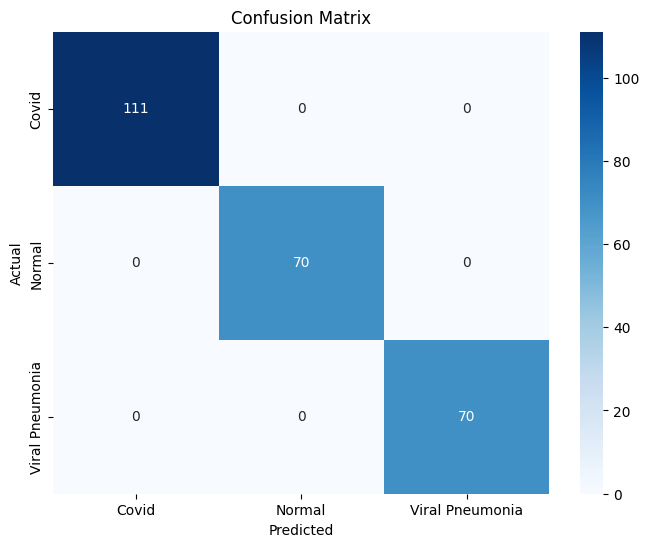

In [ ]:
#resnet50 model -- train dataset

import sklearn
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------
# Dataset path & transforms
# -------------------
path = r"E:/4th semester/python/code/Covid19-dataset/train"

transformation = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# -------------------
# Custom ImageFolder to filter out MNIST class
# -------------------
class FilteredImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        classes, class_to_idx = super().find_classes(directory)
        if "MNIST" in classes:
            classes.remove("MNIST")
        class_to_idx = {cls: i for i, cls in enumerate(classes)}
        return classes, class_to_idx

# Load dataset
data = FilteredImageFolder(path, transform=transformation)
loader = DataLoader(data, batch_size=32, shuffle=True)
class_names = data.classes
print("✅ Classes used:", class_names)
num_classes = len(class_names)

# -------------------
# Model: ResNet-50
# -------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
# Freeze convolutional layers
for param in model.parameters():
    param.requires_grad = False
# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

# -------------------
# Loss, optimizer, device
# -------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f} - Accuracy: {acc:.2f}%")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\n✅ Evaluation Metrics:")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-score: {f1*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


✅ Classes used: ['Covid', 'Normal', 'Viral Pneumonia']
Epoch 1/100 - Loss: 3.6206 - Accuracy: 43.94%
Epoch 2/100 - Loss: 2.5535 - Accuracy: 63.64%
Epoch 3/100 - Loss: 3.3977 - Accuracy: 34.85%
Epoch 4/100 - Loss: 2.2574 - Accuracy: 71.21%
Epoch 5/100 - Loss: 1.7841 - Accuracy: 81.82%
Epoch 6/100 - Loss: 1.8761 - Accuracy: 54.55%
Epoch 7/100 - Loss: 3.7347 - Accuracy: 45.45%
Epoch 8/100 - Loss: 1.5090 - Accuracy: 89.39%
Epoch 9/100 - Loss: 1.9714 - Accuracy: 92.42%
Epoch 10/100 - Loss: 2.0423 - Accuracy: 83.33%
Epoch 11/100 - Loss: 1.8405 - Accuracy: 83.33%
Epoch 12/100 - Loss: 1.1556 - Accuracy: 92.42%
Epoch 13/100 - Loss: 1.2379 - Accuracy: 93.94%
Epoch 14/100 - Loss: 1.4785 - Accuracy: 95.45%
Epoch 15/100 - Loss: 0.9786 - Accuracy: 90.91%
Epoch 16/100 - Loss: 1.1300 - Accuracy: 80.30%
Epoch 17/100 - Loss: 2.1627 - Accuracy: 78.79%
Epoch 18/100 - Loss: 0.8982 - Accuracy: 89.39%
Epoch 19/100 - Loss: 1.3403 - Accuracy: 93.94%
Epoch 20/100 - Loss: 1.6755 - Accuracy: 90.91%
Epoch 21/100 -

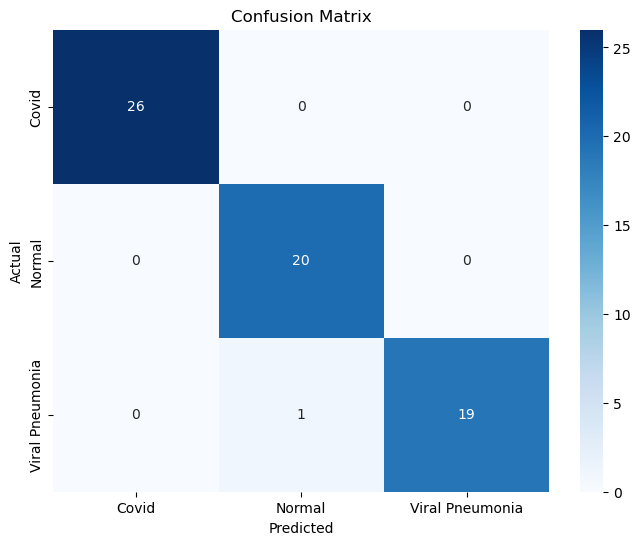

In [4]:
#resnet50 model -- test dataset

import sklearn
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------
# Dataset path & transforms
# -------------------
path = r"E:/4th semester/python/code/Covid19-dataset/test"

transformation = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# -------------------
# Custom ImageFolder to filter out MNIST class
# -------------------
class FilteredImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        classes, class_to_idx = super().find_classes(directory)
        if "MNIST" in classes:
            classes.remove("MNIST")
        class_to_idx = {cls: i for i, cls in enumerate(classes)}
        return classes, class_to_idx

# Load dataset
data = FilteredImageFolder(path, transform=transformation)
loader = DataLoader(data, batch_size=32, shuffle=True)
class_names = data.classes
print("✅ Classes used:", class_names)
num_classes = len(class_names)

# -------------------
# Model: ResNet-50
# -------------------
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
# Freeze convolutional layers
for param in model.parameters():
    param.requires_grad = False
# Replace final layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

# -------------------
# Loss, optimizer, device
# -------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.fc.parameters(), lr=1e-3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f} - Accuracy: {acc:.2f}%")
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\n✅ Evaluation Metrics:")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-score: {f1*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [1]:
!pip3 install scikit-learn 

Defaulting to user installation because normal site-packages is not writeable


✅ Classes used: ['Covid', 'Normal', 'Viral Pneumonia']
Epoch 1/100 - Loss: 5.7954 - Accuracy: 68.92%
Epoch 2/100 - Loss: 3.1992 - Accuracy: 85.26%
Epoch 3/100 - Loss: 2.6132 - Accuracy: 90.84%
Epoch 4/100 - Loss: 2.4291 - Accuracy: 87.65%
Epoch 5/100 - Loss: 2.0363 - Accuracy: 91.24%
Epoch 6/100 - Loss: 1.6680 - Accuracy: 90.84%
Epoch 7/100 - Loss: 1.6659 - Accuracy: 93.23%
Epoch 8/100 - Loss: 1.4924 - Accuracy: 92.83%
Epoch 9/100 - Loss: 1.5433 - Accuracy: 94.42%
Epoch 10/100 - Loss: 1.4590 - Accuracy: 94.02%
Epoch 11/100 - Loss: 1.4691 - Accuracy: 94.02%
Epoch 12/100 - Loss: 1.4377 - Accuracy: 92.83%
Epoch 13/100 - Loss: 1.3310 - Accuracy: 93.63%
Epoch 14/100 - Loss: 1.4355 - Accuracy: 95.22%
Epoch 15/100 - Loss: 1.0500 - Accuracy: 96.02%
Epoch 16/100 - Loss: 1.0773 - Accuracy: 94.02%
Epoch 17/100 - Loss: 1.2824 - Accuracy: 95.22%
Epoch 18/100 - Loss: 0.9936 - Accuracy: 95.62%
Epoch 19/100 - Loss: 0.9403 - Accuracy: 95.22%
Epoch 20/100 - Loss: 0.9136 - Accuracy: 95.62%
Epoch 21/100 -

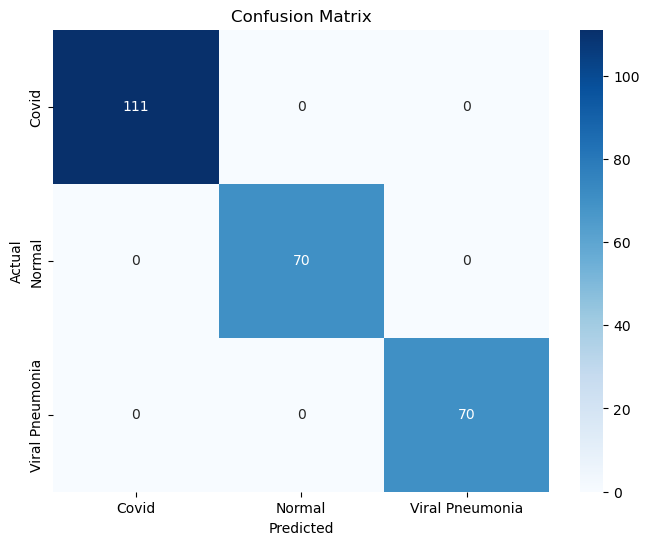

In [2]:
#VGG -16 model - train dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------
# Dataset path & transforms
# -------------------
path = r"E:/4th semester/python/code/Covid19-dataset/train"

transformation = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# -------------------
# Custom ImageFolder to filter out MNIST class
# -------------------
class FilteredImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        classes, class_to_idx = super().find_classes(directory)
        if "MNIST" in classes:
            classes.remove("MNIST")
        class_to_idx = {cls: i for i, cls in enumerate(classes)}
        return classes, class_to_idx

# Load dataset
data = FilteredImageFolder(path, transform=transformation)
loader = DataLoader(data, batch_size=32, shuffle=True)
class_names = data.classes
print("✅ Classes used:", class_names)
num_classes = len(class_names)

# -------------------
# Model: VGG16
# -------------------
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
# Freeze convolutional layers
for param in model.features.parameters():
    param.requires_grad = False
# Replace classifier's final layer
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

# -------------------
# Loss, optimizer, device
# -------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[6].parameters(), lr=1e-3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# -------------------
# Training loop
# -------------------
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f} - Accuracy: {acc:.2f}%")

# -------------------
# Evaluation
# -------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\n✅ Evaluation Metrics:")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-score: {f1*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

✅ Classes used: ['Covid', 'Normal', 'Viral Pneumonia']
Epoch 1/100 - Loss: 3.2499 - Accuracy: 40.91%
Epoch 2/100 - Loss: 1.6035 - Accuracy: 72.73%
Epoch 3/100 - Loss: 1.9907 - Accuracy: 81.82%
Epoch 4/100 - Loss: 1.0288 - Accuracy: 78.79%
Epoch 5/100 - Loss: 0.9030 - Accuracy: 89.39%
Epoch 6/100 - Loss: 0.6714 - Accuracy: 84.85%
Epoch 7/100 - Loss: 0.8240 - Accuracy: 90.91%
Epoch 8/100 - Loss: 0.6163 - Accuracy: 92.42%
Epoch 9/100 - Loss: 0.5270 - Accuracy: 92.42%
Epoch 10/100 - Loss: 0.7606 - Accuracy: 92.42%
Epoch 11/100 - Loss: 0.3492 - Accuracy: 96.97%
Epoch 12/100 - Loss: 0.4437 - Accuracy: 92.42%
Epoch 13/100 - Loss: 0.2993 - Accuracy: 95.45%
Epoch 14/100 - Loss: 0.3698 - Accuracy: 98.48%
Epoch 15/100 - Loss: 0.3740 - Accuracy: 93.94%
Epoch 16/100 - Loss: 0.6144 - Accuracy: 95.45%
Epoch 17/100 - Loss: 0.1984 - Accuracy: 98.48%
Epoch 18/100 - Loss: 0.1958 - Accuracy: 100.00%
Epoch 19/100 - Loss: 0.2913 - Accuracy: 96.97%
Epoch 20/100 - Loss: 0.2995 - Accuracy: 93.94%
Epoch 21/100 

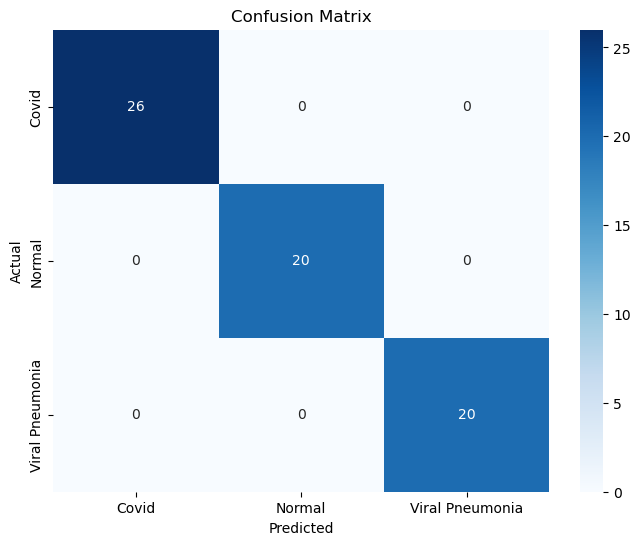

In [3]:
#VGG -16 model - test dataset
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms, models
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -------------------
# Dataset path & transforms
# -------------------
path = r"E:/4th semester/python/code/Covid19-dataset/test"

transformation = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

# -------------------
# Custom ImageFolder to filter out MNIST class
# -------------------
class FilteredImageFolder(datasets.ImageFolder):
    def find_classes(self, directory):
        classes, class_to_idx = super().find_classes(directory)
        if "MNIST" in classes:
            classes.remove("MNIST")
        class_to_idx = {cls: i for i, cls in enumerate(classes)}
        return classes, class_to_idx

# Load dataset
data = FilteredImageFolder(path, transform=transformation)
loader = DataLoader(data, batch_size=32, shuffle=True)
class_names = data.classes
print("✅ Classes used:", class_names)
num_classes = len(class_names)

# -------------------
# Model: VGG16
# -------------------
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
# Freeze convolutional layers
for param in model.features.parameters():
    param.requires_grad = False
# Replace classifier's final layer
model.classifier[6] = nn.Linear(model.classifier[6].in_features, num_classes)

# -------------------
# Loss, optimizer, device
# -------------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier[6].parameters(), lr=1e-3)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

# -------------------
# Training loop
# -------------------
num_epochs = 100

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        preds = outputs.argmax(dim=1)
        correct += (preds == y).sum().item()
        total += y.size(0)
    
    acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f} - Accuracy: {acc:.2f}%")

# -------------------
# Evaluation
# -------------------
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        outputs = model(x)
        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# Metrics
accuracy = accuracy_score(all_labels, all_preds)
precision = precision_score(all_labels, all_preds, average='weighted', zero_division=0)
recall = recall_score(all_labels, all_preds, average='weighted', zero_division=0)
f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)

print(f"\n✅ Evaluation Metrics:")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Precision: {precision*100:.2f}%")
print(f"Recall: {recall*100:.2f}%")
print(f"F1-score: {f1*100:.2f}%")

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names, cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()